In [12]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, Annotated
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import operator
load_dotenv()

True

In [13]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Feedback on the essay")
    score: int = Field(description="Score for the essay", ge=0, le=10)

model = ChatGroq(model="llama-3.3-70b-versatile")

structure_model = model.with_structured_output(EvaluationSchema)

In [14]:
class EssayStates(TypedDict):
    essay: str
    grammar_feedback: str
    content_feedback: str
    individual_score: Annotated[list[int], operator.add]
    final_feedback: str
    avg_score: float

In [15]:
def grammar_evaluation(state: EssayStates) -> dict:
    prompt = f"Evaluate the grammar of the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    response = structure_model.invoke(prompt)
    return {"grammar_feedback": response.feedback, "individual_score": [response.score]}

In [16]:
def content_evaluation(state: EssayStates) -> dict:
    prompt = f"Evaluate the content of the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    response = structure_model.invoke(prompt)
    return {"content_feedback": response.feedback, "individual_score": [response.score]}

In [17]:
def summary_evaluation(state: EssayStates) -> dict:
    avg_score = sum(state['individual_score']) / len(state['individual_score'])
    final_feedback = f"Overall, the essay received an average score of {avg_score:.2f}. Grammar feedback: {state['grammar_feedback']}. Content feedback: {state['content_feedback']}."
    return {"final_feedback": final_feedback, "avg_score": avg_score}

In [18]:
graph = StateGraph(EssayStates)

graph.add_node("Grammar Evaluation", grammar_evaluation)
graph.add_node("Content Evaluation", content_evaluation)
graph.add_node("Summary Evaluation", summary_evaluation)

graph.add_edge(START, "Grammar Evaluation")
graph.add_edge(START, "Content Evaluation")
graph.add_edge("Grammar Evaluation", "Summary Evaluation")
graph.add_edge("Content Evaluation", "Summary Evaluation")
graph.add_edge("Summary Evaluation", END)


In [19]:
workflow = graph.compile()

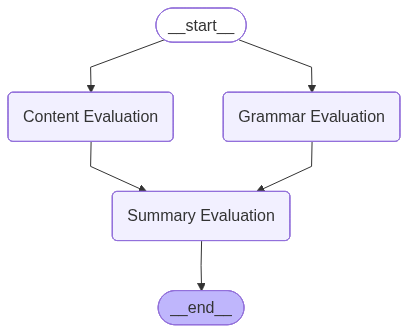

In [20]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [21]:
essay = """In the world of technology, artificial intelligence (AI) has become a transformative force, revolutionizing various industries and reshaping the way we live and work. AI refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. The impact of AI can be seen in fields such as healthcare, finance, transportation, and entertainment, where it has enabled advancements in diagnostics, personalized medicine, autonomous vehicles, and content creation. However, as AI continues to evolve, it also raises ethical concerns regarding privacy, bias, and job displacement. It is crucial for society to navigate these challenges responsibly while harnessing the potential benefits of AI for a better future."""

In [22]:
initial_state = {"essay": essay}

result = workflow.invoke(initial_state)

print(result)

{'essay': 'In the world of technology, artificial intelligence (AI) has become a transformative force, revolutionizing various industries and reshaping the way we live and work. AI refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. The impact of AI can be seen in fields such as healthcare, finance, transportation, and entertainment, where it has enabled advancements in diagnostics, personalized medicine, autonomous vehicles, and content creation. However, as AI continues to evolve, it also raises ethical concerns regarding privacy, bias, and job displacement. It is crucial for society to navigate these challenges responsibly while harnessing the potential benefits of AI for a better future.', 'grammar_feedback': "The essay demonstrates excellent grammar, with proper use of commas, semicolons, and transition words. The sentence structure is varied and clear, making it easy to follow the author's arguments. However, there are a 

In [23]:
result['final_feedback']

"Overall, the essay received an average score of 8.00. Grammar feedback: The essay demonstrates excellent grammar, with proper use of commas, semicolons, and transition words. The sentence structure is varied and clear, making it easy to follow the author's arguments. However, there are a few areas where the language could be more concise and engaging. For example, the phrase 'reshaping the way we live and work' is a bit clichéd and could be rephrased for more impact. Additionally, the sentence 'It is crucial for society to navigate these challenges responsibly while harnessing the potential benefits of AI for a better future' feels a bit like a non-sequitur and could be more effectively integrated into the rest of the essay. Overall, the grammar is strong, but the writing could benefit from a bit more attention to style and flow.. Content feedback: The essay provides a clear and concise introduction to the concept of artificial intelligence and its impact on various industries. It als

In [24]:
result['avg_score']

8.0